In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/users/gangmuk/projects/aibrix-gangmuk/benchmarks/data-driven-routing/routing-agent-service/training_data/temp/all/data-processed.csv')

print(f"df.columns: {list(df.columns)}")

#df.columns: ['request_id', 'selected_pod', 'input_tokens', 'output_tokens', 'total_tokens', 'ttft', 'avg_tpot', 'e2e_latency', 'pod_0000-kv_hit_ratio', 'pod_0000-inflight_requests', 'pod_0000-gpu_kv_cache', 'pod_0000-cpu_kv_cache', 'pod_0000-running_requests', 'pod_0000-waiting_requests', 'pod_0000-decode_tokens', 'pod_0001-kv_hit_ratio', 'pod_0001-inflight_requests', 'pod_0001-gpu_kv_cache', 'pod_0001-cpu_kv_cache', 'pod_0001-running_requests', 'pod_0001-waiting_requests', 'pod_0001-decode_tokens', 'pod_0002-kv_hit_ratio', 'pod_0002-inflight_requests', 'pod_0002-gpu_kv_cache', 'pod_0002-cpu_kv_cache', 'pod_0002-running_requests', 'pod_0002-waiting_requests', 'pod_0002-decode_tokens', 'pod_0003-kv_hit_ratio', 'pod_0003-inflight_requests', 'pod_0003-gpu_kv_cache', 'pod_0003-cpu_kv_cache', 'pod_0003-running_requests', 'pod_0003-waiting_requests', 'pod_0003-decode_tokens', 'pod_0004-kv_hit_ratio', 'pod_0004-inflight_requests', 'pod_0004-gpu_kv_cache', 'pod_0004-cpu_kv_cache', 'pod_0004-running_requests', 'pod_0004-waiting_requests', 'pod_0004-decode_tokens', 'pod_0005-kv_hit_ratio', 'pod_0005-inflight_requests', 'pod_0005-gpu_kv_cache', 'pod_0005-cpu_kv_cache', 'pod_0005-running_requests', 'pod_0005-waiting_requests', 'pod_0005-decode_tokens', 'pod_0006-kv_hit_ratio', 'pod_0006-inflight_requests', 'pod_0006-gpu_kv_cache', 'pod_0006-cpu_kv_cache', 'pod_0006-running_requests', 'pod_0006-waiting_requests', 'pod_0006-decode_tokens', 'action', 'avg_tpot_slo_satisfied', 'avg_ttft_slo_satisfied', 'ttft_reward', 'tpot_reward', 'reward', 'processing_timestamp', 'ttft_slo_used', 'avg_tpot_slo_used', 'source_file', 'ttft_reward_weight_used', 'reward_function_used']

df.columns: ['request_id', 'selected_pod', 'input_tokens', 'output_tokens', 'total_tokens', 'ttft', 'avg_tpot', 'e2e_latency', 'request_start_time', 'request_end_time', 'pod_0000-kv_hit_ratio', 'pod_0000-inflight_requests', 'pod_0000-gpu_kv_cache', 'pod_0000-cpu_kv_cache', 'pod_0000-running_requests', 'pod_0000-waiting_requests', 'pod_0000-decode_tokens', 'pod_0001-kv_hit_ratio', 'pod_0001-inflight_requests', 'pod_0001-gpu_kv_cache', 'pod_0001-cpu_kv_cache', 'pod_0001-running_requests', 'pod_0001-waiting_requests', 'pod_0001-decode_tokens', 'pod_0002-kv_hit_ratio', 'pod_0002-inflight_requests', 'pod_0002-gpu_kv_cache', 'pod_0002-cpu_kv_cache', 'pod_0002-running_requests', 'pod_0002-waiting_requests', 'pod_0002-decode_tokens', 'pod_0003-kv_hit_ratio', 'pod_0003-inflight_requests', 'pod_0003-gpu_kv_cache', 'pod_0003-cpu_kv_cache', 'pod_0003-running_requests', 'pod_0003-waiting_requests', 'pod_0003-decode_tokens', 'pod_0004-kv_hit_ratio', 'pod_0004-inflight_requests', 'pod_0004-gpu_kv_cac

Found 7 GPU KV cache columns for pods: ['pod_0000', 'pod_0001', 'pod_0002', 'pod_0003', 'pod_0004', 'pod_0005', 'pod_0006']


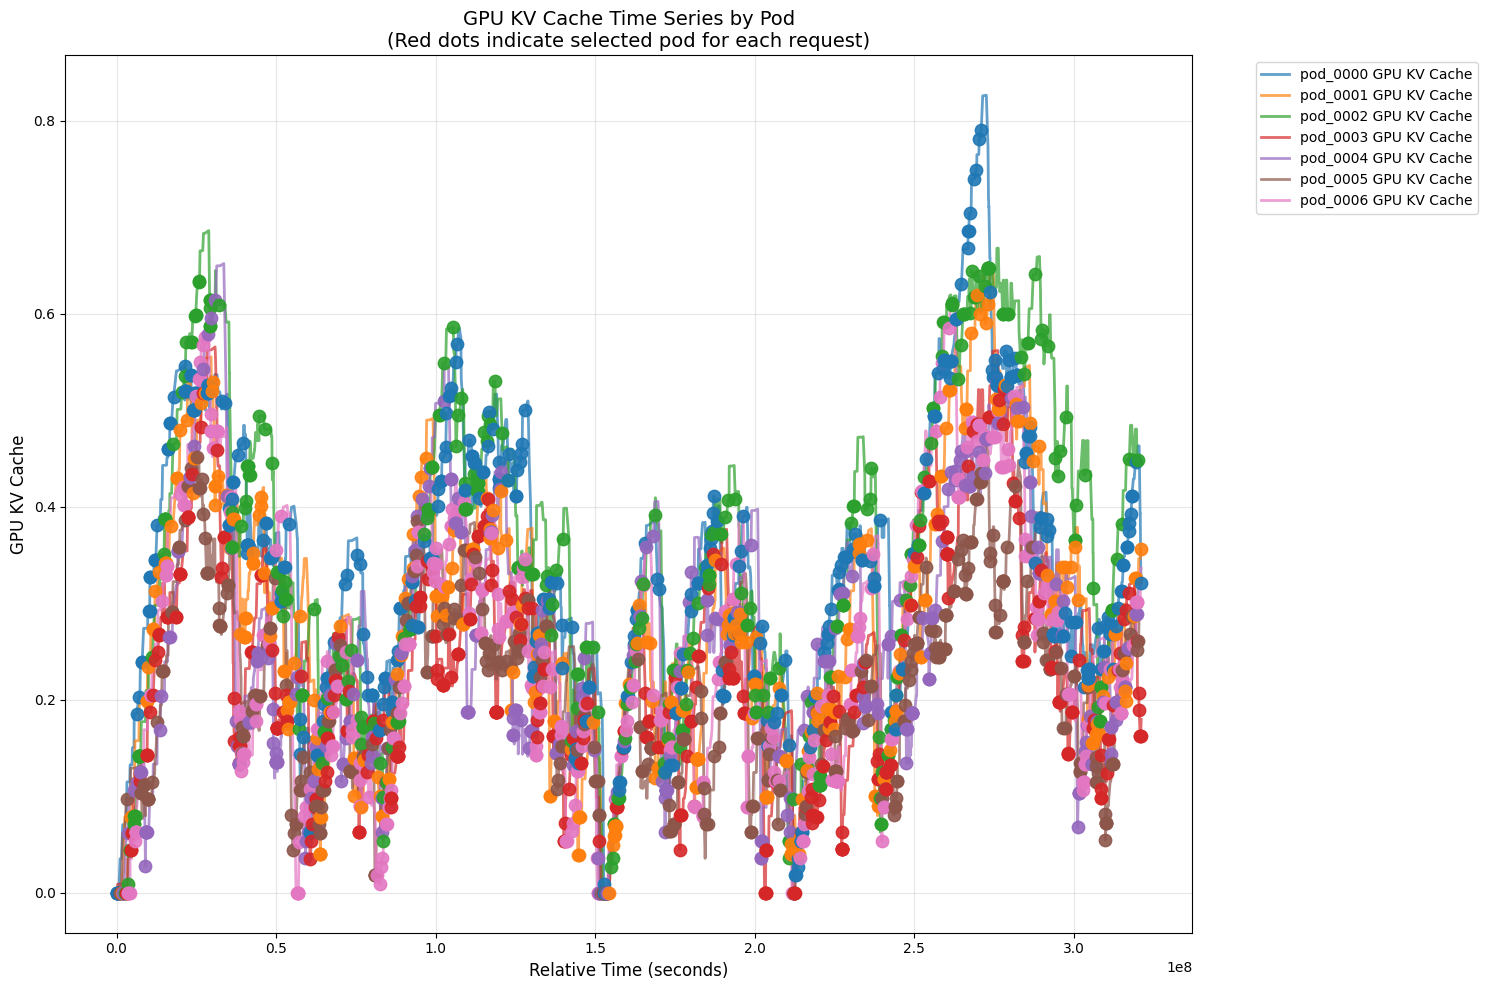

In [7]:
df = df.sort_values('request_start_time').reset_index(drop=True)
# df = df.sort_values('request_end_time').reset_index(drop=True)

# Convert request_start_time to relative time starting from 0
df['relative_request_start_time'] = df['request_start_time'] - df['request_start_time'].min()
df['relative_request_end_time'] = df['request_end_time'] - df['request_end_time'].min()

# Extract GPU KV cache columns for all pods
gpu_kv_cache_cols = [col for col in df.columns if 'gpu_kv_cache' in col]
pod_names = [col.split('-')[0] for col in gpu_kv_cache_cols]

print(f"Found {len(gpu_kv_cache_cols)} GPU KV cache columns for pods: {pod_names}")

# Create the plot
plt.figure(figsize=(15, 10))

# Plot GPU KV cache for each pod as time series
colors = plt.cm.tab10(range(len(gpu_kv_cache_cols)))
for i, (col, pod_name, color) in enumerate(zip(gpu_kv_cache_cols, pod_names, colors)):
    plt.plot(df['relative_request_start_time'], df[col], label=f'{pod_name} GPU KV Cache', alpha=0.7, linewidth=2, color=color)
    # plt.plot(df['relative_request_end_time'], df[col], label=f'{pod_name} GPU KV Cache', alpha=0.7, linewidth=2, color=color)

# Highlight selected pods with markers
for idx, row in df.iterrows():
    selected_pod = row['selected_pod']
    selected_col = f'{selected_pod}-gpu_kv_cache'
    if selected_col in df.columns:
        # Find the color for this pod
        pod_idx = pod_names.index(selected_pod)
        pod_color = colors[pod_idx]
        plt.scatter(row['relative_request_start_time'], row[selected_col], color=pod_color, s=80, marker='o', alpha=0.9, zorder=5, linewidth=1)
        # plt.scatter(row['relative_request_end_time'], row[selected_col], color=pod_color, s=80, marker='o', alpha=0.9, zorder=5, linewidth=1)

# Add legend entry for selected pods
# plt.scatter([], [], color='red', s=80, marker='o', label='Selected Pod (for each request)', alpha=0.9, edgecolors='black', linewidth=2)

plt.xlabel('Relative Time (seconds)', fontsize=12)
plt.ylabel('GPU KV Cache', fontsize=12)
plt.title('GPU KV Cache Time Series by Pod\n(Red dots indicate selected pod for each request)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()